In [1]:
!pip install nlpaug

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 7.7 MB/s eta 0:00:00:00:01


In [2]:
# Cell 1: Imports
import os, gc, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
from tqdm.auto import tqdm
from torch.cuda.amp import GradScaler, autocast
import nlpaug.augmenter.word as naw
from torch.optim.lr_scheduler import ReduceLROnPlateau


warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {device} | GPUs: {torch.cuda.device_count()}")


2025-09-07 06:23:14.004303: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757226194.335205      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757226194.429902      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✅ Device: cuda | GPUs: 2


In [3]:
# Cell 2: Config + Seeding
config = {
    "epochs": 15,
    "batch_size": 64,
    "max_length": 128,
    "k_folds": 8,
    "learning_rate": 2e-5,
    "model_name": "bert-large-uncased",
    "early_stop_patience": 3,
    "seed": 42,
    "use_amp": True,
    "num_workers": 0
}

random.seed(config["seed"])
np.random.seed(config["seed"])
torch.manual_seed(config["seed"])
torch.cuda.manual_seed_all(config["seed"])
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


In [4]:
# Cell 3: Load Dataset
# Load dataset
df = pd.read_csv("/kaggle/input/promise_nfr_original.csv", sep=";")
print(f"✅ Loaded {len(df)} samples")

# Map: F = 1 (functional), everything else = 0 (non-functional)
df["label"] = df["class"].apply(lambda x: 1 if x == "F" else 0)

# Drop missing texts
df.dropna(subset=["RequirementText", "label"], inplace=True)

# Compute pos_weight for functional class (label 1)
num_nfr = len(df) - df["label"].sum()  # Number of non-functional (0)
num_f = df["label"].sum()  # Number of functional (1)
pos_weight = num_nfr / num_f  # ~1.45 based on dataset stats
print(f"✅ Pos weight for functional class: {pos_weight:.2f}")

# Log
print(f"✅ After mapping: {len(df)} rows")
print("📊 Class distribution:\n", df["label"].value_counts())
print("🧐 Unique class types:", df["class"].unique())


def augment_texts(texts, labels, aug_ratio=1.0):
    aug = naw.SynonymAug(aug_src='wordnet', aug_max=3)  # Synonym replacement
    augmented_texts, augmented_labels = [], []
    for text, label in zip(texts, labels):
        augmented_texts.append(text)  # Original text
        augmented_labels.append(label)
        if label == 1:  # Augment only functional
            for _ in range(int(aug_ratio)):
                augmented_text = aug.augment(text)
                # nlpaug returns a list; take the first element (single string)
                augmented_texts.append(augmented_text[0] if isinstance(augmented_text, list) else augmented_text)
                augmented_labels.append(label)
    return pd.Series(augmented_texts), pd.Series(augmented_labels)

✅ Loaded 625 samples
✅ Pos weight for functional class: 1.45
✅ After mapping: 625 rows
📊 Class distribution:
 label
0    370
1    255
Name: count, dtype: int64
🧐 Unique class types: ['PE' 'LF' 'US' 'A' 'SE' 'F' 'FT' 'SC' 'PO' 'O' 'L' 'MN']


In [5]:
# Cell 4: Dataset & Tokenizer
tokenizer = BertTokenizer.from_pretrained(config["model_name"])

class RequirementsDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts.tolist(), truncation=True, padding=True, max_length=config["max_length"])
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

    def __len__(self):
        return len(self.labels)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

In [6]:
class BERT_BiLSTM_Attention(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = BertModel.from_pretrained(config["model_name"])
        self.lstm = nn.LSTM(self.bert.config.hidden_size, 128, batch_first=True, bidirectional=True)
        self.attn = nn.Linear(256, 1)
        self.dropout = nn.Dropout(0.5)  # Add dropout
        self.fc = nn.Linear(256, 1)

    def forward(self, input_ids, attention_mask):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        lstm_out, _ = self.lstm(bert_out)
        weights = torch.softmax(self.attn(lstm_out), dim=1)
        context = torch.sum(weights * lstm_out, dim=1)
        context = self.dropout(context)  # Apply dropout
        logits = self.fc(context)
        return logits.squeeze(-1)

In [7]:
# Cell 6: Train / Eval Functions
def train_fn(model, loader, optimizer, criterion, scaler, fold, epoch):
    model.train()
    total_loss = 0
    pbar = tqdm(loader, desc=f"🟡 Fold {fold+1} | Epoch {epoch+1} [Train]")
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        with autocast(enabled=config["use_amp"]):
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

        if config["use_amp"]:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix(loss=loss.item())
    return total_loss / len(loader)


def eval_fn(model, loader, criterion, fold, epoch):
    model.eval()
    total_loss = 0
    preds, trues = [], []
    pbar = tqdm(loader, desc=f"🔵 Fold {fold+1} | Epoch {epoch+1} [Eval]")

    with torch.no_grad():
        for batch in pbar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            total_loss += loss.item()

            preds += torch.sigmoid(logits).round().cpu().numpy().tolist()
            trues += labels.cpu().numpy().tolist()
            pbar.set_postfix(loss=loss.item())

    f1 = f1_score(trues, preds)
    return total_loss / len(loader), f1, preds, trues


In [8]:
# Cell 7: K-Fold Training
import nltk
import os
nltk.download('averaged_perceptron_tagger_eng', download_dir='/kaggle/working/nltk_data', quiet=True)
nltk.download('wordnet', download_dir='/kaggle/working/nltk_data', quiet=True)
nltk.download('omw-1.4', download_dir='/kaggle/working/nltk_data', quiet=True)
nltk.data.path.append('/kaggle/working/nltk_data')
print("✅ NLTK resources downloaded and path updated.")

scaler = GradScaler()
skf = StratifiedKFold(n_splits=config["k_folds"], shuffle=True, random_state=config["seed"])

results = {"fold": [], "precision": [], "recall": [], "f1": []}
all_preds, all_trues = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(df["RequirementText"], df["label"])):
    print(f"\n🔁 Fold {fold+1}/{config['k_folds']}")
    train_texts = df.iloc[train_idx]["RequirementText"]
    train_labels = df.iloc[train_idx]["label"]
    val_texts = df.iloc[val_idx]["RequirementText"]
    val_labels = df.iloc[val_idx]["label"]

    # Add augmentation here
    train_texts, train_labels = augment_texts(train_texts, train_labels, aug_ratio=1.0)  # Adjust ratio as needed

    model = BERT_BiLSTM_Attention().to(device)
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)

    optimizer = AdamW(model.parameters(), lr=config["learning_rate"])
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1, verbose=True)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))
    
    train_dataset = RequirementsDataset(train_texts, train_labels)
    val_dataset = RequirementsDataset(val_texts, val_labels)
    train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True,
                              num_workers=config["num_workers"], pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=config["batch_size"],
                            num_workers=config["num_workers"], pin_memory=True)

    best_f1 = 0
    patience = 0

    for epoch in range(config["epochs"]):
        train_loss = train_fn(model, train_loader, optimizer, criterion, scaler, fold, epoch)
        val_loss, val_f1, preds, trues = eval_fn(model, val_loader, criterion, fold, epoch)
        print(f"✅ Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")
        scheduler.step(val_f1)  # Reduce LR if F1 doesn't improve
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_preds, best_trues = preds, trues
            patience = 0
        else:
            patience += 1
            if patience >= config["early_stop_patience"]:
                print("⏹️ Early stopping triggered")
                break

    # Log final scores
    precision = precision_score(best_trues, best_preds)
    recall = recall_score(best_trues, best_preds)
    f1 = f1_score(best_trues, best_preds)
    print(f"\n📊 Fold {fold+1} Scores — Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    print(classification_report(best_trues, best_preds, target_names=["NFR", "F"]))

    results["fold"].append(fold + 1)
    results["precision"].append(precision)
    results["recall"].append(recall)
    results["f1"].append(f1)
    all_preds.extend(best_preds)
    all_trues.extend(best_trues)

    del model
    gc.collect()
    torch.cuda.empty_cache()

✅ NLTK resources downloaded and path updated.

🔁 Fold 1/8


model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

🟡 Fold 1 | Epoch 1 [Train]:   0%|          | 0/13 [00:00<?, ?it/s]

🔵 Fold 1 | Epoch 1 [Eval]:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Epoch 1 | Train Loss: 0.7929 | Val Loss: 0.7532 | Val F1: 0.5926


...

🔵 Fold 8 | Epoch 6 [Eval]:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Epoch 6 | Train Loss: 0.0457 | Val Loss: 0.2675 | Val F1: 0.8667


🟡 Fold 8 | Epoch 7 [Train]:   0%|          | 0/13 [00:00<?, ?it/s]

🔵 Fold 8 | Epoch 7 [Eval]:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Epoch 7 | Train Loss: 0.0360 | Val Loss: 0.2188 | Val F1: 0.9032
⏹️ Early stopping triggered

📊 Fold 8 Scores — Precision: 0.9667, Recall: 0.9062, F1: 0.9355
              precision    recall  f1-score   support

         NFR       0.94      0.98      0.96        46
           F       0.97      0.91      0.94        32

    accuracy                           0.95        78
   macro avg       0.95      0.94      0.95        78
weighted avg       0.95      0.95      0.95        78




📊 Mean CV Scores:
      fold  precision    recall        f1
mean   4.5   0.940446  0.898059  0.917513

📋 Overall Classification Report:
              precision    recall  f1-score   support

         NFR       0.93      0.96      0.95       370
           F       0.94      0.90      0.92       255

    accuracy                           0.93       625
   macro avg       0.94      0.93      0.93       625
weighted avg       0.93      0.93      0.93       625



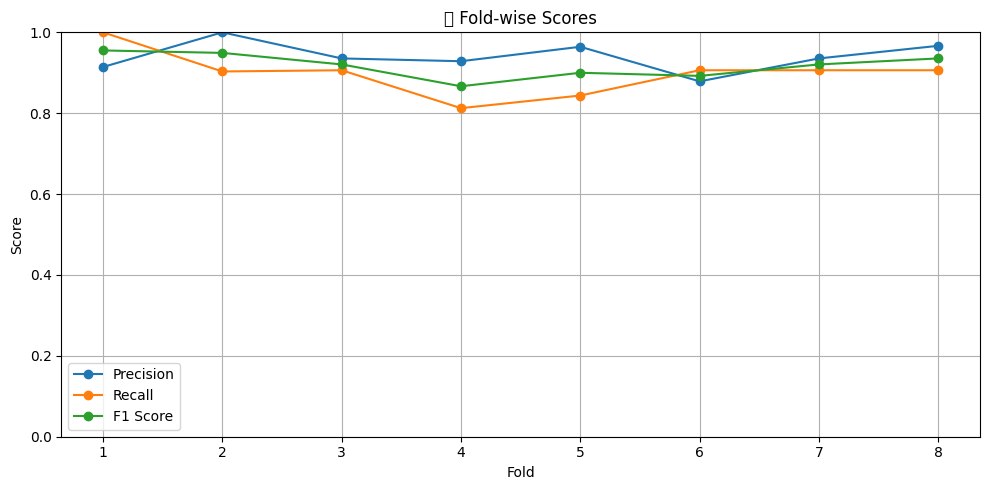

In [9]:
# Cell 8: Report + Plot
results_df = pd.DataFrame(results)
print("\n📊 Mean CV Scores:")
print(results_df.describe().loc[["mean"]])

print("\n📋 Overall Classification Report:")
print(classification_report(all_trues, all_preds, target_names=["NFR", "F"]))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(results_df["fold"], results_df["precision"], label="Precision", marker="o")
plt.plot(results_df["fold"], results_df["recall"], label="Recall", marker="o")
plt.plot(results_df["fold"], results_df["f1"], label="F1 Score", marker="o")
plt.xticks(results_df["fold"])
plt.title("📈 Fold-wise Scores")
plt.ylim(0, 1)
plt.xlabel("Fold")
plt.ylabel("Score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
# Install SHAP if needed
!pip install shap
import shap



# ==============================
# 🟢 FINAL MODEL TRAINING ON FULL DATA
# ==============================
pd.set_option("display.max_colwidth", None)  # Show full text in DataFrame
print("\n🟢 Training final model on full dataset for SHAP explanations...")
print(f"✅ Using {torch.cuda.device_count()} GPUs")

full_dataset = RequirementsDataset(df['RequirementText'], df['label'])
full_loader = DataLoader(full_dataset, batch_size=config["batch_size"], shuffle=True, num_workers=config["num_workers"], pin_memory=True)

final_model = BERT_BiLSTM_Attention().to(device)
if torch.cuda.device_count() >= 2:
    final_model = nn.DataParallel(final_model, device_ids=[0, 1])  # Use 2 GPUs
    print("✅ Model wrapped with DataParallel for 2 GPUs")
else:
    print("⚠️ Fewer than 2 GPUs detected; using available device")

optimizer = AdamW(final_model.parameters(), lr=config["learning_rate"])
criterion = nn.BCEWithLogitsLoss()

for epoch in range(config["epochs"]):
    train_loss = train_fn(final_model, full_loader, optimizer, criterion, scaler, fold=-1, epoch=epoch)
    print(f"Final Training Epoch {epoch+1}/{config['epochs']} | Loss: {train_loss:.4f}")

# ==============================
# 🔍 SHAP Explainability on Final Model
# ==============================
try:
    final_model.eval()

    def predict(texts):
        enc = tokenizer(list(texts), truncation=True, padding=True,
                        max_length=config["max_length"], return_tensors="pt")
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            outputs = final_model(enc["input_ids"], enc["attention_mask"])
            return torch.sigmoid(outputs).cpu().numpy()

    # Background & explainer
    background = df['RequirementText'].sample(20, random_state=42).tolist()
    masker = shap.maskers.Text(tokenizer)
    explainer = shap.Explainer(predict, masker, algorithm="partition")

    # Pick test samples
    sample_df = df.sample(10, random_state=0)  # More examples for final run
    test_samples = sample_df["RequirementText"].tolist()
    true_labels = sample_df["label"].tolist()

    # Run SHAP
    shap_values = explainer(test_samples)

    # Collect results into table
    table_rows = []
    preds = (predict(test_samples) > 0.5).astype(int).flatten()

    for i, text in enumerate(test_samples):
        token_scores = list(zip(shap_values.data[i], shap_values.values[i].flatten()))
        token_scores_sorted = sorted(token_scores, key=lambda x: abs(x[1]), reverse=True)

        positive_tokens = [tok for tok, score in token_scores_sorted if score > 0][:5]
        negative_tokens = [tok for tok, score in token_scores_sorted if score < 0][:5]

        if preds[i] == 1:  # Functional
            rationale = (
                f"Predicted **Functional** due to terms like {', '.join(positive_tokens)} "
                f"that describe concrete actions or measurable constraints."
            )
            if negative_tokens:
                rationale += f" Less weight was given to terms like {', '.join(negative_tokens)}."
        else:  # Non-Functional
            rationale = (
                f"Predicted **Non-Functional** due to quality-related terms like {', '.join(positive_tokens)}, "
                f"highlighting performance/attributes instead of actions."
            )
            if negative_tokens:
                rationale += f" Words like {', '.join(negative_tokens)} were down-weighted."

        table_rows.append({
            "Requirement": text,
            "Actual Class": "Functional" if true_labels[i] == 1 else "Non-Functional",
            "Predicted Class": "Functional" if preds[i] == 1 else "Non-Functional",
            "Explanation": rationale
        })

    shap_table = pd.DataFrame(table_rows)
    display(shap_table)
    shap_table.to_csv("shap_explanations_final.csv", index=False)

except Exception as e:
    print(f"⚠️ SHAP failed on final model: {e}")


🟢 Training final model on full dataset for SHAP explanations...
✅ Using 2 GPUs
✅ Model wrapped with DataParallel for 2 GPUs


🟡 Fold 0 | Epoch 1 [Train]:   0%|          | 0/10 [00:00<?, ?it/s]

Final Training Epoch 1/15 | Loss: 0.6554


🟡 Fold 0 | Epoch 2 [Train]:   0%|          | 0/10 [00:00<?, ?it/s]

Final Training Epoch 2/15 | Loss: 0.5198


...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 10/10 [01:35<00:00, 10.81s/it]

  0%|          | 0/462 [00:00<?, ?it/s]

PartitionExplainer explainer: 11it [01:49, 10.99s/it]                        


,Requirement,Actual Class,Predicted Class,Explanation
0,The System shall meet all applicable accounting standards. The final version of the System must successfully pass independent audit performed by a certified auditor.,Non-Functional,Non-Functional,"Predicted **Non-Functional** due to quality-related terms like shall, audit, the, applicable, accounting, highlighting performance/attributes instead of actions. Words like meet, successfully, version, standards, must were down-weighted."
1,The product must be able to interface with any HTML browser. The product shall transmit data between the user and the product without problems. The product shall display HTML properly in 80% of all HTML browsers tested (minimum is to test 8 browsers).,Non-Functional,Non-Functional,"Predicted **Non-Functional** due to quality-related terms like minimum, shall, between, the, data, highlighting performance/attributes instead of actions. Words like without, %, properly, html, browser were down-weighted."
2,Only registered customers can purchase streaming movies.,Non-Functional,Non-Functional,"Predicted **Non-Functional** due to quality-related terms like movies, streaming, purchase, , highlighting performance/attributes instead of actions. Words like only, customers, ., can, registered were down-weighted."
3,The product shall be able to be installed in any operating environment within 2 days.,Non-Functional,Non-Functional,"Predicted **Non-Functional** due to quality-related terms like shall, the, able, be, highlighting performance/attributes instead of actions. Words like installed, within, days, product, in were down-weighted."
4,Only authorized personnel can access sales information.,Non-Functional,Non-Functional,"Predicted **Non-Functional** due to quality-related terms like sales, information, access, , highlighting performance/attributes instead of actions. Words like only, ., authorized, can, personnel were down-weighted."
5,90% of untrained realtors shall be able to install the product on their device without printed instructions,Non-Functional,Non-Functional,"Predicted **Non-Functional** due to quality-related terms like their, instructions, printed, shall, real, highlighting performance/attributes instead of actions. Words like %, train, un, able, of were down-weighted."
6,The product shall free of computer viruses.,Non-Functional,Non-Functional,"Predicted **Non-Functional** due to quality-related terms like shall, , highlighting performance/attributes instead of actions. Words like product, ., the, computer, free were down-weighted."
7,Website shall allow customers to purchase pre-paid cards of $5 $10 or $20 value either by credit card or mail-in payment option.,Functional,Functional,"Predicted **Functional** due to terms like shall, either, -, mail, website that describe concrete actions or measurable constraints. Less weight was given to terms like customers, -, ., 10."
8,On a 112k connection or faster the system response time for all operations must be no more than 3 seconds 90% of the time.,Non-Functional,Non-Functional,"Predicted **Non-Functional** due to quality-related terms like the, operations, or, all, for, highlighting performance/attributes instead of actions. Words like 112, connection, k, system, % were down-weighted."
9,Users shall feel satisfied using the product. 85% of all users will be satisfied with the product.,Non-Functional,Non-Functional,"Predicted **Non-Functional** due to quality-related terms like shall, the, users, ., the, highlighting performance/attributes instead of actions. Words like satisfied, feel, product, users, % were down-weighted."
